In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import types
from pathlib import Path

# Use fixed project root for this local workspace
ROOT = Path(r"D:/NIB-main")
if not (ROOT / "scripts").exists():
    raise FileNotFoundError(f"Cannot find scripts folder under {ROOT}")

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Avoid conflict with site-packages module named 'scripts'
SCRIPTS_DIR = ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# Force 'scripts' package to resolve to local project folder
local_scripts_pkg = types.ModuleType("scripts")
local_scripts_pkg.__path__ = [str(SCRIPTS_DIR)]
sys.modules["scripts"] = local_scripts_pkg

import torch
import clip
from plot import visualize_vandt_heatmap
from salicncy import chefer, fast_ig, gradcam, m2ib, mfaba, nib, rise, saliencymap
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizerFast
from PIL import Image, ImageOps

os.environ["TOKENIZERS_PARALLELISM"] = "false"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Project root:", ROOT)
print("CWD:", Path.cwd())

Project root: D:\NIB-main
CWD: D:\NIB-main


In [3]:
def plot(tokenizer,processor, image_path, text, vmap, tmap, bb=None):
    # Preprocess image
    image = Image.open(image_path).convert('RGB')
    # Tokenize text
    text_ids = torch.tensor([tokenizer.encode(text, add_special_tokens=True)]).to(device)
    text_words = tokenizer.convert_ids_to_tokens(text_ids[0].tolist())
    image_under = processor(images=image, return_tensors="pt", do_normalize=False)['pixel_values'][0].permute(1,2,0) # no normalization
    if bb:
        scaled_bb = []
        for x, y, w, h in bb:
            hr, vr = image_under.shape[0]/image.size[0], image_under.shape[1]/image.size[1]
            scaled_bb.append((x*hr, y*vr, w*hr, h*vr))
        bb = scaled_bb
    visualize_vandt_heatmap(tmap, vmap, text_words, image_under, bb=bb)

In [2]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
tokenizer = CLIPTokenizerFast.from_pretrained("openai/clip-vit-base-patch32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

# Visualize

In [4]:
def generate_plot(img_path,text,method):
    image = Image.open(img_path).convert('RGB')
    image_feat = processor(images=image, return_tensors="pt")['pixel_values'].to(device)
    image_features = model.get_image_features(image_feat)
    text_ids = torch.tensor([tokenizer.encode(text, add_special_tokens=True)]).to(device)
    text_words = tokenizer.convert_ids_to_tokens(text_ids[0].tolist())
    text_features = model.get_text_features(text_ids)

    if method in [chefer,fast_ig,gradcam,mfaba,saliencymap]:
        vmap, tmap = method(model, processor, [text], [image])
    elif method == rise:
        vmap, tmap = rise(model, image_feat,[text_ids],image_features,text_features)
        tmap = [tmap[0].detach().cpu().numpy()]
    elif method == m2ib:
        vmap, tmap = m2ib(model, [text_ids], image_feat, 0.1)
    elif method == nib:
        vmap, tmap = nib(model, [text_ids], image_feat,10, 9)
    if vmap.shape[1] == 3:
        vmap = vmap.mean(1)
    plot(tokenizer, processor, img_path, text, vmap.squeeze(), tmap[0])

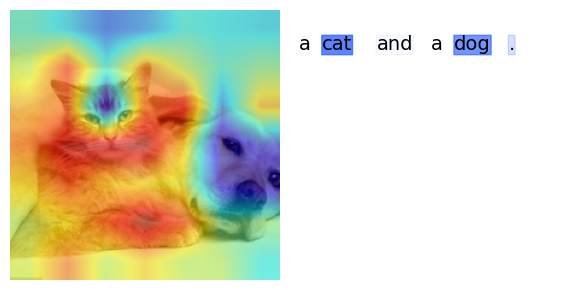

In [5]:
img_path = "images/cat-dog.jpg"
text = "a cat and a dog."

generate_plot(img_path,text,nib)

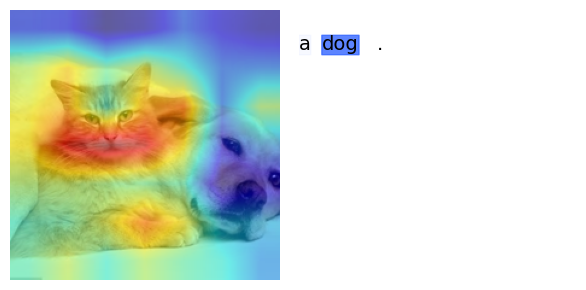

In [6]:
text = "a dog."
generate_plot(img_path,text,nib)

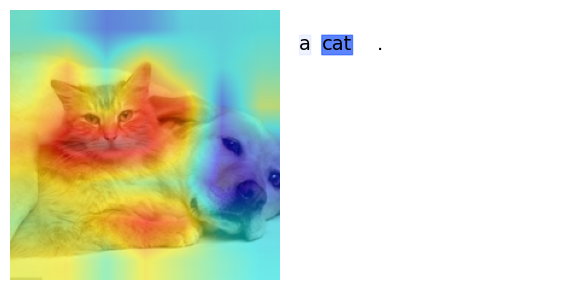

In [7]:
text = "a cat."
generate_plot(img_path,text,nib)